# Assessment of Maintenance of Public University Hostels in Nigeria
### University of Ibadan, September 2026

Akinwunmi Michael O | Daramfon Ini Umoh 

230218 | 230225
 
ESM516 —  Administration of Public Property
DR. DEBOLA ADEYEMO

---

107 students filled out a 13-item questionnaire between September 21 and 29, 2026. The survey covered hostel conditions, breakdown frequency, reporting and response time, management perception, and satisfaction.

The analysis follows the questionnaire order, Q1 through Q13, then adds a cross-analysis section and a final interactive report.

In [15]:
# setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, ttest_ind
import json
import re
from pathlib import Path
from collections import Counter
from IPython.display import IFrame, display, Markdown

pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

Path('output_figures').mkdir(exist_ok=True)

# colours I'll use throughout
BLUE   = '#1f4e79'
RED    = '#e74c3c'
GREEN  = '#27ae60'
AMBER  = '#f39c12'
GREY   = '#95a5a6'
PURPLE = '#8e44ad'

---
# 1. Loading the data

Raw CSV from Google Forms. Column names are long (full question text) so I rename them to short handles. Likert text gets mapped to integers.

In [16]:
# load
df = pd.read_csv('data/hostel_survey.csv')
df.columns = [c.strip() for c in df.columns]

# rename — fuzzy matched so a re-export of the forms doesn't break things
def find_col(needle, cols):
    return next((c for c in cols if needle.lower() in c.lower()), None)

cols = list(df.columns)
rename = {
    'gender':               find_col('1. gender', cols),
    'level':                find_col('level of study', cols),
    'years':                find_col('how many years', cols),
    'occupancy':            find_col('how many students live', cols),
    'cond_structural':      find_col('structural condition', cols),
    'cond_toilets':         find_col('toilets and bathrooms', cols),
    'cond_water':           find_col('water supply]', cols),
    'cond_electricity':     find_col('electricity supply', cols),
    'cond_plumbing':        find_col('plumbing and drainage', cols),
    'cond_cleanliness':     find_col('cleanliness and waste', cols),
    'cond_ventilation':     find_col('ventilation, security', cols),
    'break_water':          find_col('water supply or pumps', cols),
    'break_electricity':    find_col('electricity or lighting', cols),
    'knows_report':         find_col('official person or office', cols),
    'response_time':        find_col('how quickly are they usually fixed', cols),
    'agree_responsibility': find_col('university is responsible', cols),
    'agree_rules':          find_col('clear rules on shared', cols),
    'agree_participation':  find_col('take part in caring', cols),
    'agree_tracking':       find_col('clear system for submitting', cols),
    'agree_funding':        find_col('enough money to maintain', cols),
    'impact_academic':      find_col('academic performance (studying', cols),
    'impact_health':        find_col('health and rest', cols),
    'satisfaction':         find_col('overall, how satisfied', cols),
    'priority':             find_col('the one  maintenance problem', cols),
    'priority_reason':      find_col('why is this the most urgent', cols),
}
df = df.rename(columns={v: k for k, v in rename.items() if v})

# encode Likert scales as numbers
COND = {'Very Poor': 1, 'Poor': 2, 'Fair': 3, 'Good': 4, 'Very Good': 5}
BRK  = {'Never': 0, 'Once': 1, '2-3 times': 2.5, '4-5 times': 4.5, 'More than 5 times': 6}
AGR  = {'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5}
IMP  = {'No effect': 1, 'Slight effect': 2, 'Moderate effect': 3,
        'Strong effect': 4, 'Very strong effect': 5}
SAT  = {'Very Dissatisfied': 1, 'Dissatisfied': 2, 'Neutral': 3,
        'Satisfied': 4, 'Very Satisfied': 5}
RT   = {'Immediately (within a day)': 1, 'Within a week': 2, 'Within a month': 3,
        'After several months': 4, 'Never fixed': 5}

COND_COLS  = ['cond_structural', 'cond_toilets', 'cond_water', 'cond_electricity',
              'cond_plumbing', 'cond_cleanliness', 'cond_ventilation']
AGREE_COLS = ['agree_responsibility', 'agree_rules', 'agree_participation',
              'agree_tracking', 'agree_funding']

for c in COND_COLS:  df[c + '_n'] = df[c].map(COND)
for c in ['break_water', 'break_electricity']: df[c + '_n'] = df[c].map(BRK)
for c in AGREE_COLS: df[c + '_n'] = df[c].map(AGR)

df['impact_academic_n'] = df['impact_academic'].map(IMP)
df['impact_health_n']   = df['impact_health'].map(IMP)
df['sat_n'] = df['satisfaction'].map(SAT)
df['rt_n']  = df['response_time'].map(RT)
df['knows_n'] = (df['knows_report'].astype(str).str.strip().str.lower() == 'yes').astype(int)

# collapse the messy text categories
def simp_level(x):
    x = str(x).strip().lower()
    for n in ['100', '200', '300', '400', '500', '600']:
        if n in x: return f'{n}L'
    if any(w in x for w in ['m.sc', 'msc', 'graduate', 'graduated', 'pg']):
        return 'PG'
    return 'Other'

def simp_occ(x):
    x = str(x).strip()
    return x if x in ('1', '2', '3-4', '5-6') else ('7+' if '7' in x else 'Other')

def simp_priority(x):
    x = str(x).strip().lower()
    if 'toilet' in x or 'bathroom' in x: return 'Toilets/Bathrooms'
    if 'water' in x:                     return 'Water Supply'
    if 'electric' in x or 'wiring' in x: return 'Electricity'
    if 'overcrowd' in x:                 return 'Overcrowding'
    if 'clean' in x or 'waste' in x:     return 'Cleanliness'
    if 'plumb' in x or 'drain' in x:     return 'Plumbing'
    if 'roof' in x or 'leak' in x:       return 'Roofing'
    if 'door' in x or 'window' in x or 'lock' in x: return 'Doors/Windows'
    if 'bedbug' in x or 'bed bug' in x:  return 'Bedbugs'
    if 'kitchen' in x:                   return 'Kitchens'
    if 'stove' in x:                     return 'Cooking safety'
    return 'Multiple/Other'

df['level_c']    = df['level'].apply(simp_level)
df['occ_c']      = df['occupancy'].apply(simp_occ)
df['priority_c'] = df['priority'].apply(simp_priority)
df['gender_c']   = df['gender'].astype(str).str.strip().str.title()

# composite score for overall condition
df['cond_composite'] = df[[c + '_n' for c in COND_COLS]].mean(axis=1)
df['dissatisfied']   = (df['sat_n'] <= 2).astype(int)

N = len(df)
print(f"loaded {N} responses, {df.shape[1]} columns")
print(df[['gender_c', 'level_c', 'occ_c', 'sat_n']].head())

loaded 117 responses, 51 columns
  gender_c level_c occ_c  sat_n
0     Male    500L   5-6      1
1     Male    500L   3-4      3
2     Male    400L   3-4      1
3   Female    500L   3-4      2
4     Male    100L   3-4      4


---
# 2. Sample profile  (Q1–Q4)

Q1 gender, Q2 level, Q3 years in hall, Q4 occupants per room.


C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2071071682.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


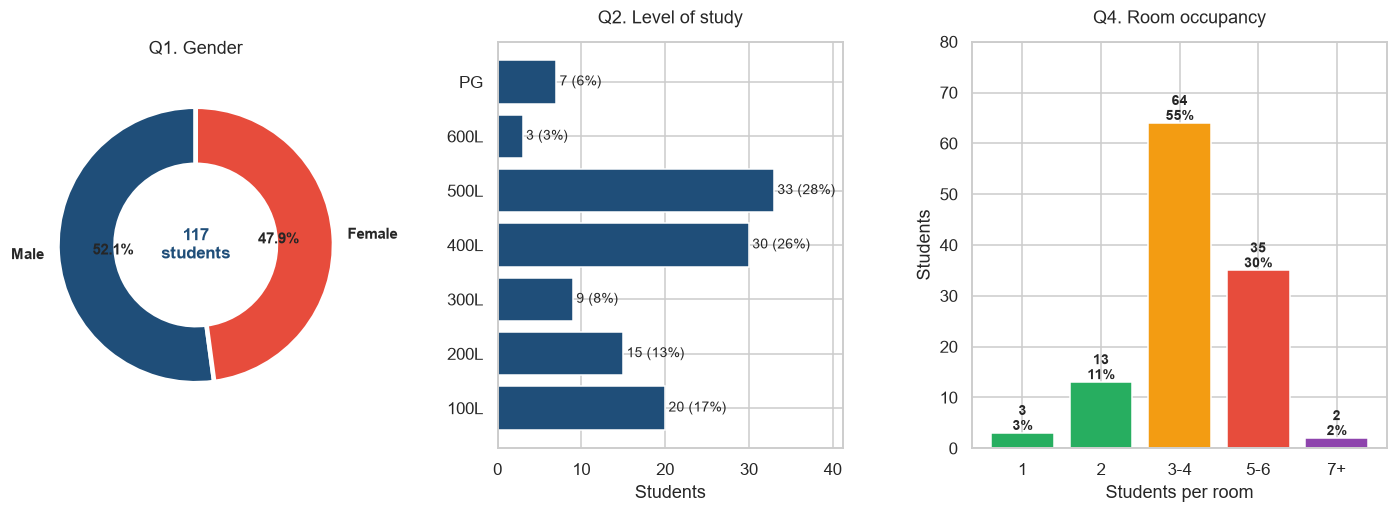

male 61 · female 56
most common level: 500L
37 students (31.6%) live in rooms with 5+ people


In [17]:
# Q1-Q4 sample profile
fig = plt.figure(figsize=(16, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.35)

# gender donut
ax1 = fig.add_subplot(gs[0, 0])
g = df['gender_c'].value_counts()
ax1.pie(g, labels=g.index, autopct='%1.1f%%', startangle=90,
        colors=[BLUE, RED],
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),
        textprops={'fontweight': 'bold', 'fontsize': 10})
ax1.text(0, 0, f"{N}\nstudents", ha='center', va='center',
         fontsize=11, fontweight='bold', color=BLUE)
ax1.set_title('Q1. Gender', pad=12)

# level bars
ax2 = fig.add_subplot(gs[0, 1])
lvl_order = ['100L', '200L', '300L', '400L', '500L', '600L', 'PG']
lvl_counts = df['level_c'].value_counts().reindex(lvl_order).dropna()
ax2.barh(lvl_counts.index, lvl_counts.values, color=BLUE, edgecolor='white')
for i, v in enumerate(lvl_counts.values):
    ax2.text(v + 0.4, i, f'{v} ({v/N*100:.0f}%)', va='center', fontsize=9)
ax2.set_xlabel('Students')
ax2.set_title('Q2. Level of study', pad=12)
ax2.set_xlim(0, lvl_counts.max() * 1.25)

# occupancy
ax3 = fig.add_subplot(gs[0, 2])
occ_order = ['1', '2', '3-4', '5-6', '7+']
occ_counts = df['occ_c'].value_counts().reindex(occ_order).dropna()
colors_occ = [GREEN, GREEN, AMBER, RED, PURPLE]
bars = ax3.bar(occ_counts.index, occ_counts.values, color=colors_occ, edgecolor='white')
for b, v in zip(bars, occ_counts.values):
    ax3.text(b.get_x() + b.get_width()/2, v + 0.6, f'{v}\n{v/N*100:.0f}%',
             ha='center', fontsize=9, fontweight='bold')
ax3.set_xlabel('Students per room')
ax3.set_ylabel('Students')
ax3.set_title('Q4. Room occupancy', pad=12)
ax3.set_ylim(0, occ_counts.max() * 1.25)

plt.tight_layout()
plt.savefig('output_figures/fig1_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# summary
over = df['occ_c'].isin(['5-6', '7+']).sum()
print(f"male {(df['gender_c']=='Male').sum()} · female {(df['gender_c']=='Female').sum()}")
print(f"most common level: {lvl_counts.idxmax()}")
print(f"{over} students ({over/N*100:.1f}%) live in rooms with 5+ people")

---
# 3. Facility condition  (Q5)

Rated seven facilities on a 5-point scale (Very Poor to Very Good). I report means with 95% confidence intervals, then the full distribution of ratings.

           Facility  Mean    SD  CI_low  CI_high
        Electricity 3.180 0.890   3.020    3.340
       Water supply 2.990 0.910   2.830    3.160
         Structural 2.850 0.840   2.690    3.000
        Cleanliness 2.470 0.990   2.290    2.650
        Ventilation 2.970 1.000   2.780    3.150
           Plumbing 2.420 0.930   2.250    2.590
Toilets & bathrooms 1.780 0.820   1.630    1.930


C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2248191793.py:52: RuntimeWarning: invalid value encountered in divide
  pct[i] = counts.values / counts.sum() * 100
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2248191793.py:52: RuntimeWarning: invalid value encountered in divide
  pct[i] = counts.values / counts.sum() * 100
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2248191793.py:52: RuntimeWarning: invalid value encountered in divide
  pct[i] = counts.values / counts.sum() * 100
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2248191793.py:52: RuntimeWarning: invalid value encountered in divide
  pct[i] = counts.values / counts.sum() * 100
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2248191793.py:52: RuntimeWarning: invalid value encountered in divide
  pct[i] = counts.values / counts.sum() * 100
C:\Users\MY PC\AppData\Local\Temp\ipykernel_14892\2248191793.py:52: RuntimeWarning: invalid value encountered in divide
  pct[i] = counts.values / counts.sum() * 100
C:\U

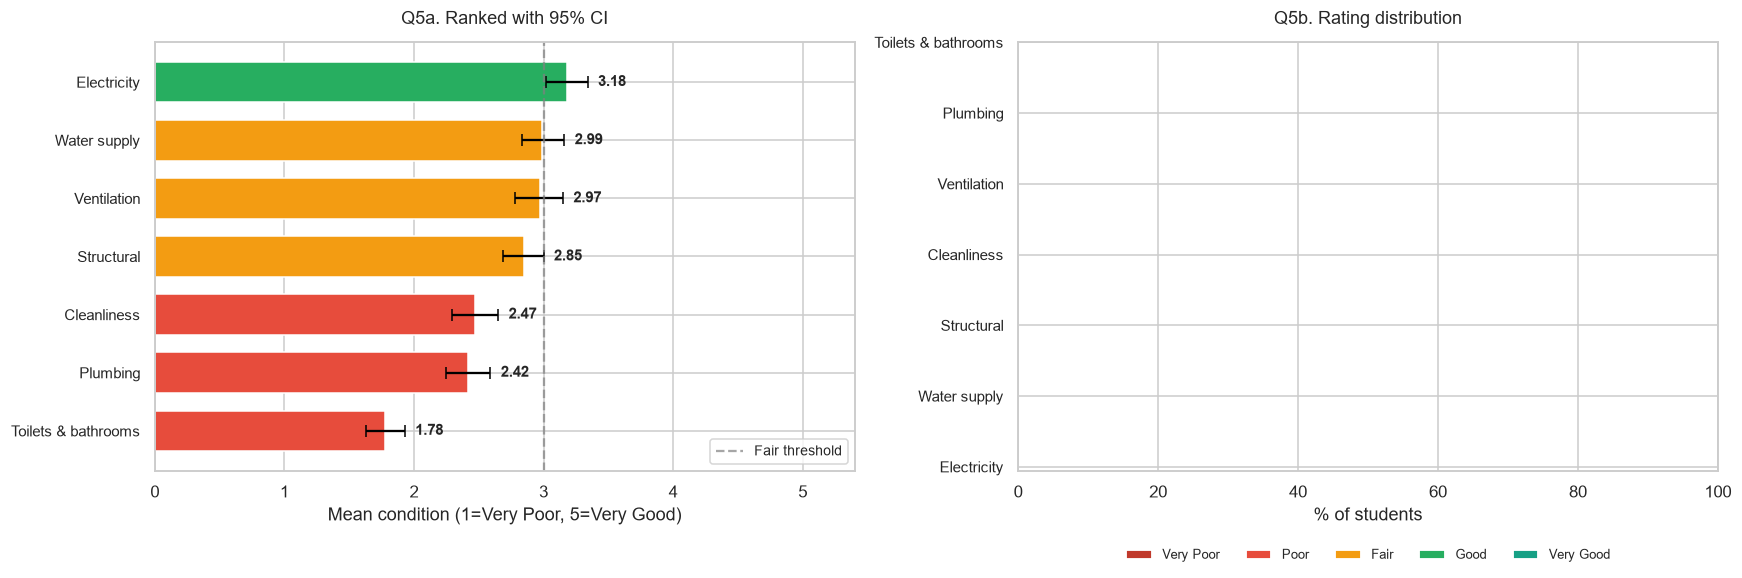


lowest: Toilets & bathrooms (1.78)
highest: Electricity (3.18)
every facility's upper CI is below 3.0 — none reach 'Fair'


In [18]:
# Q5 facility condition
facilities = {
    'cond_electricity_n': 'Electricity',
    'cond_water_n':       'Water supply',
    'cond_structural_n':  'Structural',
    'cond_cleanliness_n': 'Cleanliness',
    'cond_ventilation_n': 'Ventilation',
    'cond_plumbing_n':    'Plumbing',
    'cond_toilets_n':     'Toilets & bathrooms',
}

def describe(s, label):
    s = s.dropna()
    m, sd = s.mean(), s.std()
    se = sd / np.sqrt(len(s))
    return {'Facility': label, 'Mean': round(m, 2), 'SD': round(sd, 2),
            'CI_low': round(m - 1.96 * se, 2),
            'CI_high': round(m + 1.96 * se, 2)}

stats = pd.DataFrame([describe(df[k], v) for k, v in facilities.items()])
print(stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ranked bars with CI
ax1 = axes[0]
s_sorted = stats.sort_values('Mean')
colors = [RED if v < 2.5 else AMBER if v < 3 else GREEN for v in s_sorted['Mean']]
y = np.arange(len(s_sorted))
ax1.barh(y, s_sorted['Mean'], color=colors, edgecolor='white', height=0.7)
ax1.errorbar(s_sorted['Mean'], y,
             xerr=[s_sorted['Mean'] - s_sorted['CI_low'],
                   s_sorted['CI_high'] - s_sorted['Mean']],
             fmt='none', ecolor='black', capsize=4, lw=1.5)
for i, (v, hi) in enumerate(zip(s_sorted['Mean'], s_sorted['CI_high'])):
    ax1.text(hi + 0.08, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')
ax1.axvline(3, ls='--', color='gray', alpha=0.7, label='Fair threshold')
ax1.set_yticks(y)
ax1.set_yticklabels(s_sorted['Facility'], fontsize=10)
ax1.set_xlim(0, 5.4)
ax1.set_xlabel('Mean condition (1=Very Poor, 5=Very Good)')
ax1.set_title('Q5a. Ranked with 95% CI', pad=12)
ax1.legend(loc='lower right', fontsize=9)

# 100% stacked distribution
ax2 = axes[1]
ratings = ['Very Poor', 'Poor', 'Fair', 'Good', 'Very Good']
rating_colors = ['#c0392b', '#e74c3c', '#f39c12', '#27ae60', '#16a085']
pct = np.zeros((len(facilities), 5))
for i, k in enumerate(facilities.keys()):
    counts = df[k].value_counts().reindex(ratings).fillna(0)
    pct[i] = counts.values / counts.sum() * 100
y = np.arange(len(facilities))
left = np.zeros(len(facilities))
for j, (rt, col) in enumerate(zip(ratings, rating_colors)):
    ax2.barh(y, pct[:, j], left=left, color=col, edgecolor='white', linewidth=1.2, label=rt)
    for i in range(len(facilities)):
        if pct[i, j] > 7:
            ax2.text(left[i] + pct[i, j]/2, i, f'{pct[i,j]:.0f}%',
                     ha='center', va='center', color='white', fontsize=8.5, fontweight='bold')
    left += pct[:, j]
ax2.set_yticks(y)
ax2.set_yticklabels(list(facilities.values()), fontsize=10)
ax2.set_xlim(0, 100)
ax2.set_xlabel('% of students')
ax2.set_title('Q5b. Rating distribution', pad=12)
ax2.legend(ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.24),
           fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig('output_figures/fig2_condition.png', dpi=150, bbox_inches='tight')
plt.show()

worst = s_sorted.iloc[0]
best  = s_sorted.iloc[-1]
print(f"\nlowest: {worst['Facility']} ({worst['Mean']})")
print(f"highest: {best['Facility']} ({best['Mean']})")
print(f"every facility's upper CI is below 3.0 — none reach 'Fair'")

---
# 4. Breakdown frequency  (Q6)

Asked how often water and electricity break down per semester. Frequency is separate from condition — a facility can be rated "Fair" but fail often.

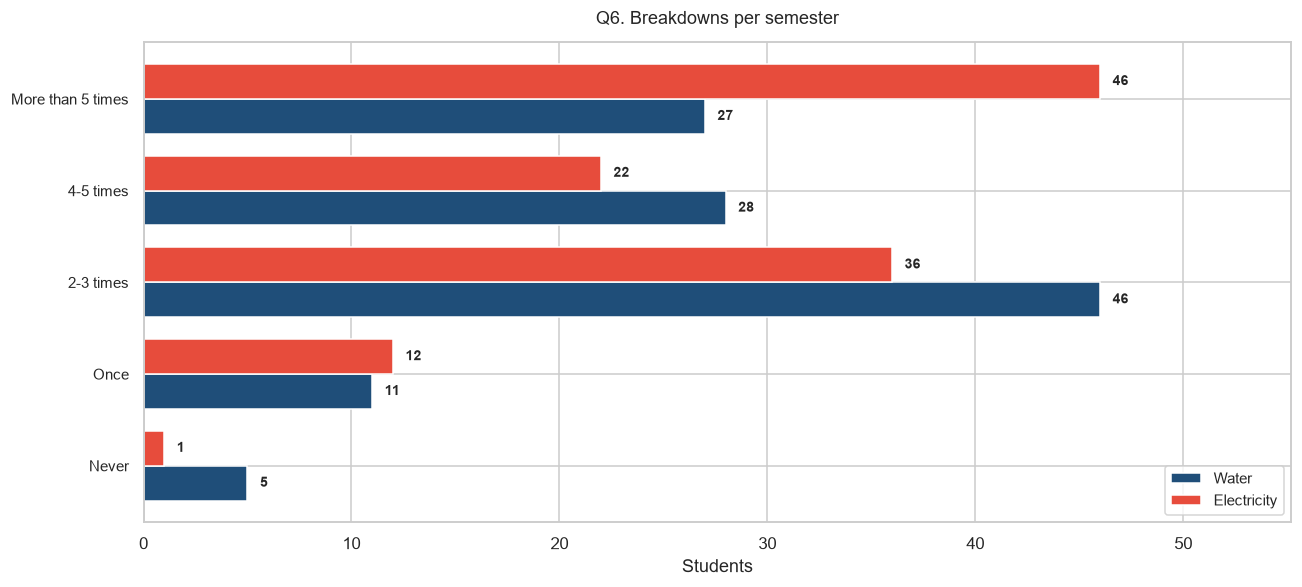

water fails 4+ times: 55 students (47%)
electricity fails 4+ times: 68 students (58%)
electricity is the more failure-prone system


In [19]:
# Q6 breakdowns
order = ['Never', 'Once', '2-3 times', '4-5 times', 'More than 5 times']
water = df['break_water'].value_counts().reindex(order).fillna(0)
elec  = df['break_electricity'].value_counts().reindex(order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5.5))
y = np.arange(len(order))
h = 0.38
b1 = ax.barh(y - h/2, water.values, height=h, color=BLUE, edgecolor='white', label='Water')
b2 = ax.barh(y + h/2, elec.values,  height=h, color=RED,  edgecolor='white', label='Electricity')
for bars in [b1, b2]:
    for b in bars:
        v = b.get_width()
        ax.text(v + 0.6, b.get_y() + b.get_height()/2, f'{int(v)}',
                va='center', fontsize=9, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(order, fontsize=10)
ax.set_xlabel('Students')
ax.set_xlim(0, max(water.max(), elec.max()) * 1.2)
ax.set_title('Q6. Breakdowns per semester', pad=12)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('output_figures/fig3_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

w_freq = df['break_water'].isin(['4-5 times', 'More than 5 times']).sum()
e_freq = df['break_electricity'].isin(['4-5 times', 'More than 5 times']).sum()
print(f"water fails 4+ times: {w_freq} students ({w_freq/N*100:.0f}%)")
print(f"electricity fails 4+ times: {e_freq} students ({e_freq/N*100:.0f}%)")
print("electricity is the more failure-prone system")

---
# 5. Reporting and response  (Q7–Q8)

Whether students know where to report problems, and how fast those problems get fixed.

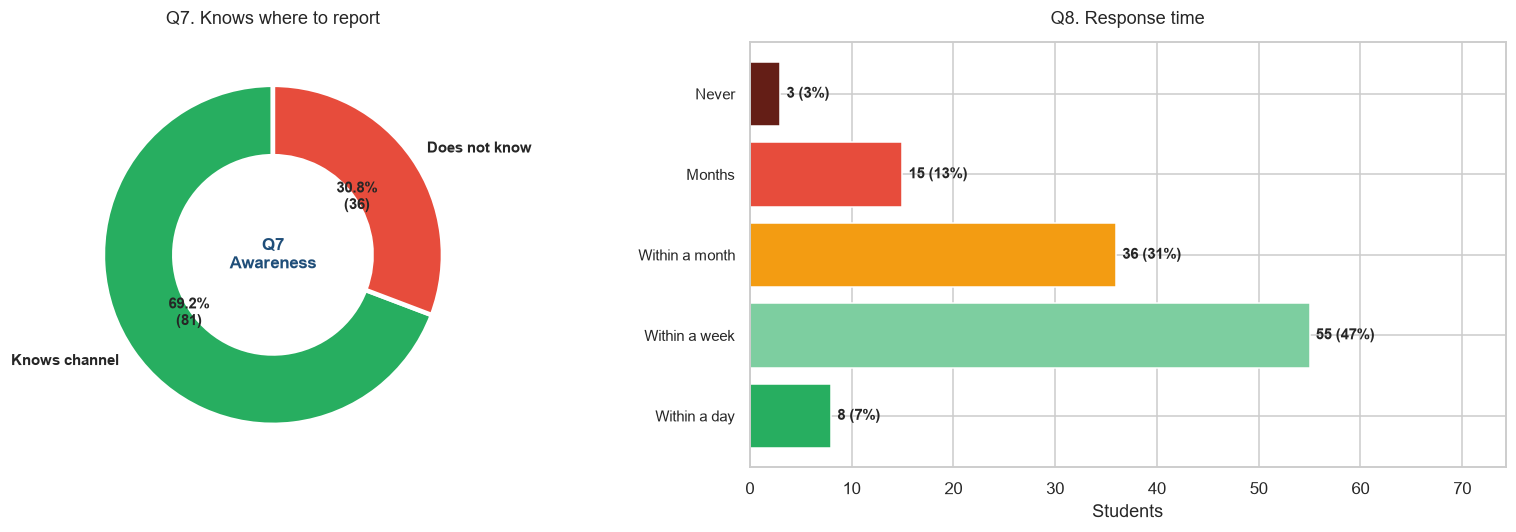

knows channel: 81 (69%)
fixed within a week: 63 (54%)
wait over a month or never fixed: 54 (46%)


In [20]:
# Q7-Q8 reporting pipeline
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Q7 donut
ax1 = axes[0]
knows = df['knows_n'].sum()
doesnt = N - knows
ax1.pie([knows, doesnt],
        labels=['Knows channel', 'Does not know'],
        autopct=lambda p: f'{p:.1f}%\n({int(round(p*N/100))})',
        startangle=90, colors=[GREEN, RED],
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),
        textprops={'fontweight': 'bold', 'fontsize': 10})
ax1.text(0, 0, "Q7\nAwareness", ha='center', va='center',
         fontsize=11, fontweight='bold', color=BLUE)
ax1.set_title('Q7. Knows where to report', pad=12)

# Q8 response time
ax2 = axes[1]
rt_order = ['Immediately (within a day)', 'Within a week', 'Within a month',
            'After several months', 'Never fixed']
rt_short = ['Within a day', 'Within a week', 'Within a month', 'Months', 'Never']
rt_counts = df['response_time'].value_counts().reindex(rt_order).fillna(0)
colors_rt = [GREEN, '#7dcea0', AMBER, RED, '#641e16']
y = np.arange(len(rt_order))
bars = ax2.barh(y, rt_counts.values, color=colors_rt, edgecolor='white')
for b, v in zip(bars, rt_counts.values):
    ax2.text(v + 0.6, b.get_y() + b.get_height()/2,
             f'{int(v)} ({v/N*100:.0f}%)', va='center', fontsize=9.5, fontweight='bold')
ax2.set_yticks(y)
ax2.set_yticklabels(rt_short, fontsize=10)
ax2.set_xlabel('Students')
ax2.set_xlim(0, rt_counts.max() * 1.35)
ax2.set_title('Q8. Response time', pad=12)

plt.tight_layout()
plt.savefig('output_figures/fig4_reporting.png', dpi=150, bbox_inches='tight')
plt.show()

slow = (df['rt_n'] >= 3).sum()
fast = (df['rt_n'] <= 2).sum()
print(f"knows channel: {knows} ({knows/N*100:.0f}%)")
print(f"fixed within a week: {fast} ({fast/N*100:.0f}%)")
print(f"wait over a month or never fixed: {slow} ({slow/N*100:.0f}%)")

---
# 6. Governance perception  (Q9)

Five agreement statements covering responsibility, rules, participation, complaint tracking, and funding.

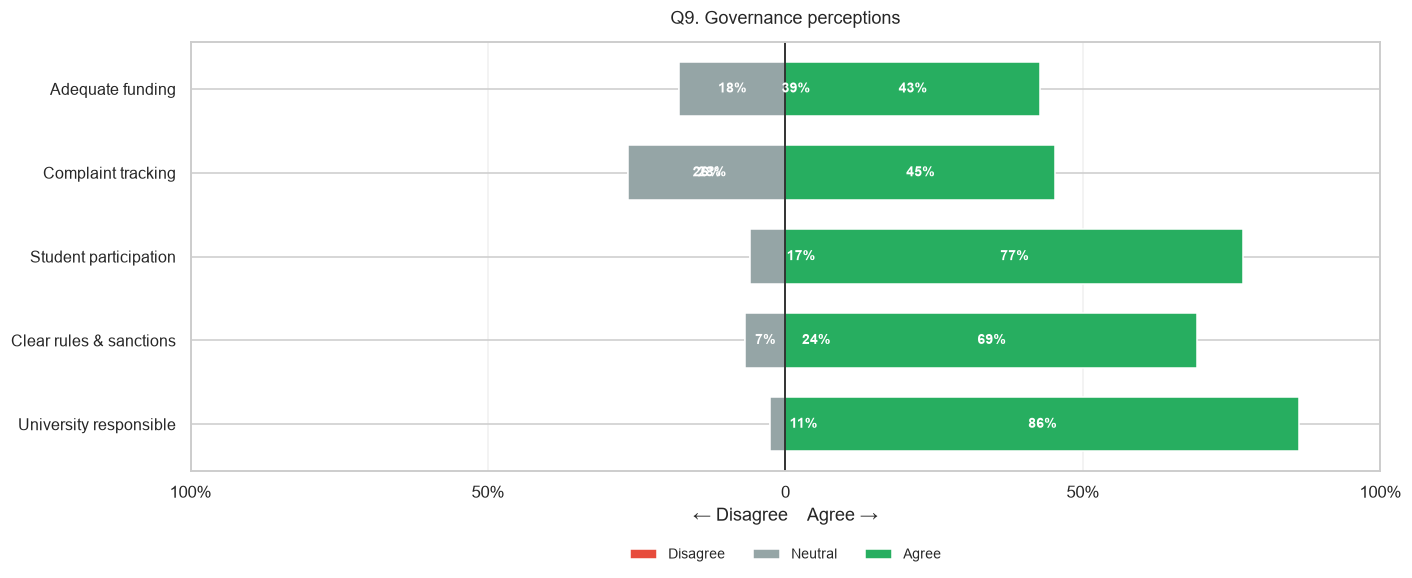

distribution per item (SD, D, N, A, SA):
  University responsible     [0.9, 1.7, 11.1, 29.1, 57.3]
  Clear rules & sanctions    [1.7, 5.1, 23.9, 32.5, 36.8]
  Student participation      [0.9, 5.1, 17.1, 44.4, 32.5]
  Complaint tracking         [12.0, 14.5, 28.2, 35.0, 10.3]
  Adequate funding           [1.7, 16.2, 39.3, 22.2, 20.5]


In [21]:
# Q9 governance
gov = {
    'agree_responsibility_n': 'University responsible',
    'agree_rules_n':          'Clear rules & sanctions',
    'agree_participation_n':  'Student participation',
    'agree_tracking_n':       'Complaint tracking',
    'agree_funding_n':        'Adequate funding',
}

# the _n columns hold integers 1..5, so count against numbers, not text
agree_levels_num = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(13, 5.5))
pct = np.zeros((len(gov), 5))
for i, k in enumerate(gov.keys()):
    counts = df[k].value_counts().reindex(agree_levels_num).fillna(0)
    pct[i] = counts.values / counts.sum() * 100

# collapse into three bands for the diverging view
disagree = pct[:, 0] + pct[:, 1]     # strongly disagree + disagree
neutral  = pct[:, 2]
agree    = pct[:, 3] + pct[:, 4]     # agree + strongly agree

y = np.arange(len(gov))
h = 0.65
ax.barh(y, -disagree, height=h, color=RED, edgecolor='white', label='Disagree')
ax.barh(y, neutral, left=-disagree, height=h, color=GREY, edgecolor='white', label='Neutral')
ax.barh(y, agree, left=0, height=h, color=GREEN, edgecolor='white', label='Agree')

for i in range(len(gov)):
    if disagree[i] > 6:
        ax.text(-disagree[i]/2, i, f'{disagree[i]:.0f}%',
                ha='center', va='center', color='white',
                fontsize=9, fontweight='bold')
    if neutral[i] > 6:
        ax.text(-disagree[i] + neutral[i]/2, i, f'{neutral[i]:.0f}%',
                ha='center', va='center', color='white',
                fontsize=9, fontweight='bold')
    if agree[i] > 6:
        ax.text(agree[i]/2, i, f'{agree[i]:.0f}%',
                ha='center', va='center', color='white',
                fontsize=9, fontweight='bold')

ax.axvline(0, color='black', lw=1)
ax.set_yticks(y)
ax.set_yticklabels(list(gov.values()), fontsize=10.5)
ax.set_xlim(-100, 100)
ax.set_xticks([-100, -50, 0, 50, 100])
ax.set_xticklabels(['100%', '50%', '0', '50%', '100%'])
ax.set_xlabel('← Disagree    Agree →')
ax.set_title('Q9. Governance perceptions', pad=12)
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.24),
          fontsize=9, frameon=False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('output_figures/fig5_governance.png', dpi=150, bbox_inches='tight')
plt.show()

# sanity check — these should each sum to ~100
print("distribution per item (SD, D, N, A, SA):")
for i, k in enumerate(gov.keys()):
    print(f"  {gov[k]:25s}  {pct[i].round(1).tolist()}")

---
# 7. Impact and satisfaction  (Q10–Q11)

Perceived effect on academics and health, plus overall satisfaction with maintenance.

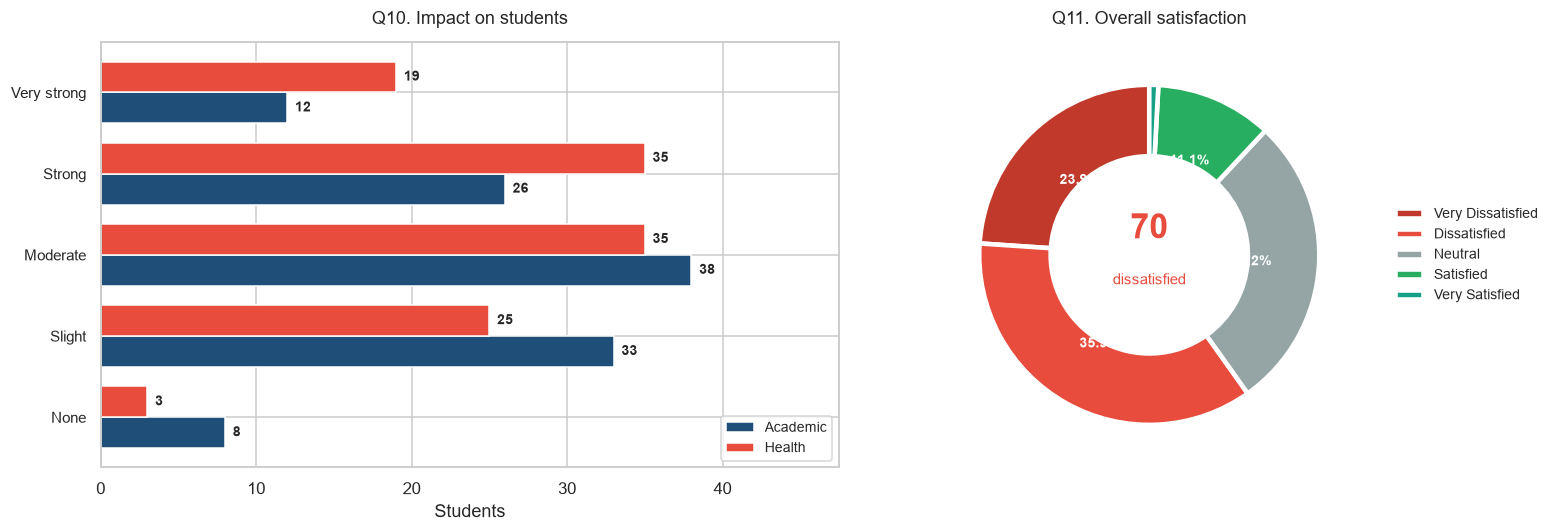

strong academic impact: 38 (32%)
strong health impact:   54 (46%)
dissatisfied: 70 (59.8%)


In [22]:
# Q10-Q11
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Q10 impact
ax1 = axes[0]
imp_order = ['No effect', 'Slight effect', 'Moderate effect', 'Strong effect', 'Very strong effect']
imp_short = ['None', 'Slight', 'Moderate', 'Strong', 'Very strong']
acad = df['impact_academic'].value_counts().reindex(imp_order).fillna(0)
heal = df['impact_health'].value_counts().reindex(imp_order).fillna(0)

y = np.arange(len(imp_order))
h = 0.38
b1 = ax1.barh(y - h/2, acad.values, height=h, color=BLUE, edgecolor='white', label='Academic')
b2 = ax1.barh(y + h/2, heal.values, height=h, color=RED, edgecolor='white', label='Health')
for bars in [b1, b2]:
    for b in bars:
        v = b.get_width()
        if v > 0:
            ax1.text(v + 0.5, b.get_y() + b.get_height()/2, str(int(v)),
                     va='center', fontsize=9, fontweight='bold')
ax1.set_yticks(y)
ax1.set_yticklabels(imp_short, fontsize=10)
ax1.set_xlabel('Students')
ax1.set_xlim(0, max(acad.max(), heal.max()) * 1.25)
ax1.set_title('Q10. Impact on students', pad=12)
ax1.legend(loc='lower right', fontsize=9)

# Q11 satisfaction
ax2 = axes[1]
sat_order = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']
sat_counts = df['satisfaction'].value_counts().reindex(sat_order).fillna(0)
sat_colors = ['#c0392b', '#e74c3c', '#95a5a6', '#27ae60', '#16a085']
ax2.pie(sat_counts, labels=None,
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle=90, colors=sat_colors,
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),
        textprops={'fontweight': 'bold', 'fontsize': 9, 'color': 'white'})
ax2.text(0, 0.15, f"{df['dissatisfied'].sum()}", ha='center', va='center',
         fontsize=22, fontweight='bold', color=RED)
ax2.text(0, -0.15, "dissatisfied", ha='center', va='center', fontsize=10, color=RED)
ax2.set_title('Q11. Overall satisfaction', pad=12)
ax2.legend(sat_order, loc='center left', bbox_to_anchor=(1.05, 0.5),
           fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('output_figures/fig6_impact_sat.png', dpi=150, bbox_inches='tight')
plt.show()

a_strong = (df['impact_academic_n'] >= 4).sum()
h_strong = (df['impact_health_n'] >= 4).sum()
print(f"strong academic impact: {a_strong} ({a_strong/N*100:.0f}%)")
print(f"strong health impact:   {h_strong} ({h_strong/N*100:.0f}%)")
print(f"dissatisfied: {df['dissatisfied'].sum()} ({df['dissatisfied'].mean()*100:.1f}%)")

---
# 8. Priorities  (Q12–Q13)

Q12 asked students to pick the single most urgent problem. Q13 asked why. I chart the top priorities with a Pareto view, then pull out the most common words from the free-text answers.

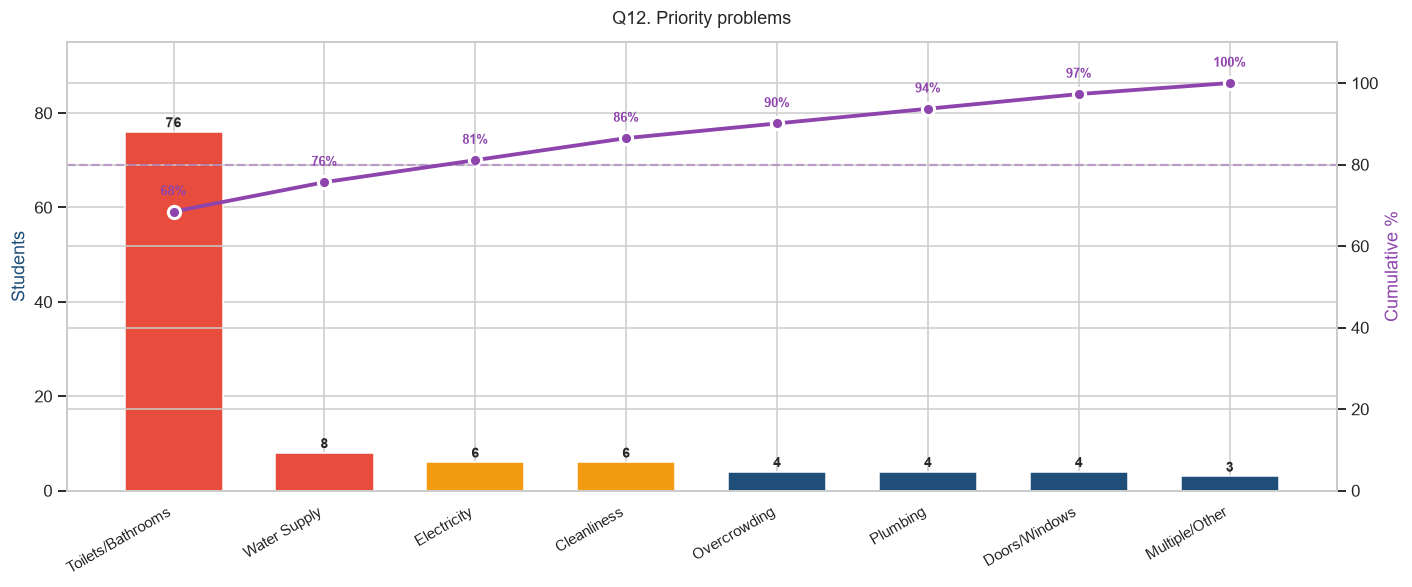

top: Toilets/Bathrooms (76 students, 65%)
top 2 cover 76% of all requests


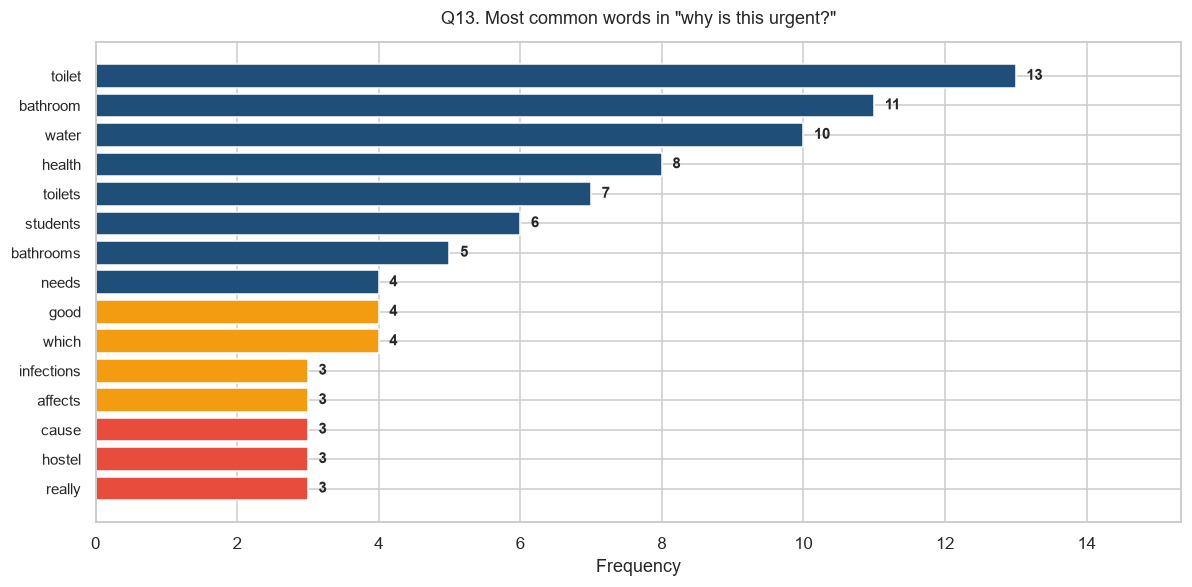

In [23]:
# Q12 pareto + Q13 keyword extraction
pri_counts = df['priority_c'].value_counts().head(8)
labels = pri_counts.index.tolist()
values = pri_counts.values
cum = np.cumsum(values) / values.sum() * 100

fig, ax1 = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(labels))
colors = [RED if i < 2 else AMBER if i < 4 else BLUE for i in range(len(labels))]
ax1.bar(x, values, color=colors, edgecolor='white', width=0.65)
for xi, v in zip(x, values):
    ax1.text(xi, v + 1, str(int(v)), ha='center', fontsize=9, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=9.5)
ax1.set_ylabel('Students', color=BLUE)
ax1.set_ylim(0, values.max() * 1.25)

ax2 = ax1.twinx()
ax2.plot(x, cum, color=PURPLE, marker='o', markersize=8, linewidth=2.5,
         markeredgecolor='white', markeredgewidth=2, label='Cumulative %')
for xi, c in zip(x, cum):
    ax2.text(xi, c + 4, f'{c:.0f}%', ha='center', fontsize=8.5,
             color=PURPLE, fontweight='bold')
ax2.set_ylabel('Cumulative %', color=PURPLE)
ax2.set_ylim(0, 110)
ax2.axhline(80, ls='--', color=PURPLE, alpha=0.4)

ax1.set_title('Q12. Priority problems', pad=12)

plt.tight_layout()
plt.savefig('output_figures/fig7_priority.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"top: {labels[0]} ({values[0]} students, {values[0]/N*100:.0f}%)")
print(f"top 2 cover {cum[1]:.0f}% of all requests")

# Q13 keyword extraction — quick scan of free text
stop = set(['the','a','an','and','is','it','in','of','to','for','that','this','with',
            'on','be','are','as','at','by','or','they','their','them','our','we','i',
            'not','but','so','if','when','because','from','has','have','was','were',
            'you','your','my','me','can','will','would','should','could','very','also',
            'just','like','get','got','there','here','all','any','some','no','yes',
            'more','most','into','out','up','down','than','then','only','over','use'])
text = ' '.join(df['priority_reason'].dropna().astype(str))
words = re.findall(r'\b[a-z]{4,}\b', text.lower())
kw = Counter(w for w in words if w not in stop).most_common(15)

fig, ax = plt.subplots(figsize=(11, 5.5))
words_, counts_ = zip(*kw[::-1])
colors_kw = [RED if i < 3 else AMBER if i < 7 else BLUE for i in range(len(words_))]
bars = ax.barh(range(len(words_)), counts_, color=colors_kw, edgecolor='white')
for b, c in zip(bars, counts_):
    ax.text(b.get_width() + 0.15, b.get_y() + b.get_height()/2, str(c),
            va='center', fontsize=9.5, fontweight='bold')
ax.set_yticks(range(len(words_)))
ax.set_yticklabels(words_, fontsize=10)
ax.set_xlabel('Frequency')
ax.set_title('Q13. Most common words in "why is this urgent?"', pad=12)
ax.set_xlim(0, max(counts_) * 1.18)

plt.tight_layout()
plt.savefig('output_figures/fig8_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 9. Cross-analysis

Three questions cut across the survey:

1. Does overcrowding relate to worse conditions?
2. Are male and female students affected differently?
3. Does facility condition actually drive satisfaction?

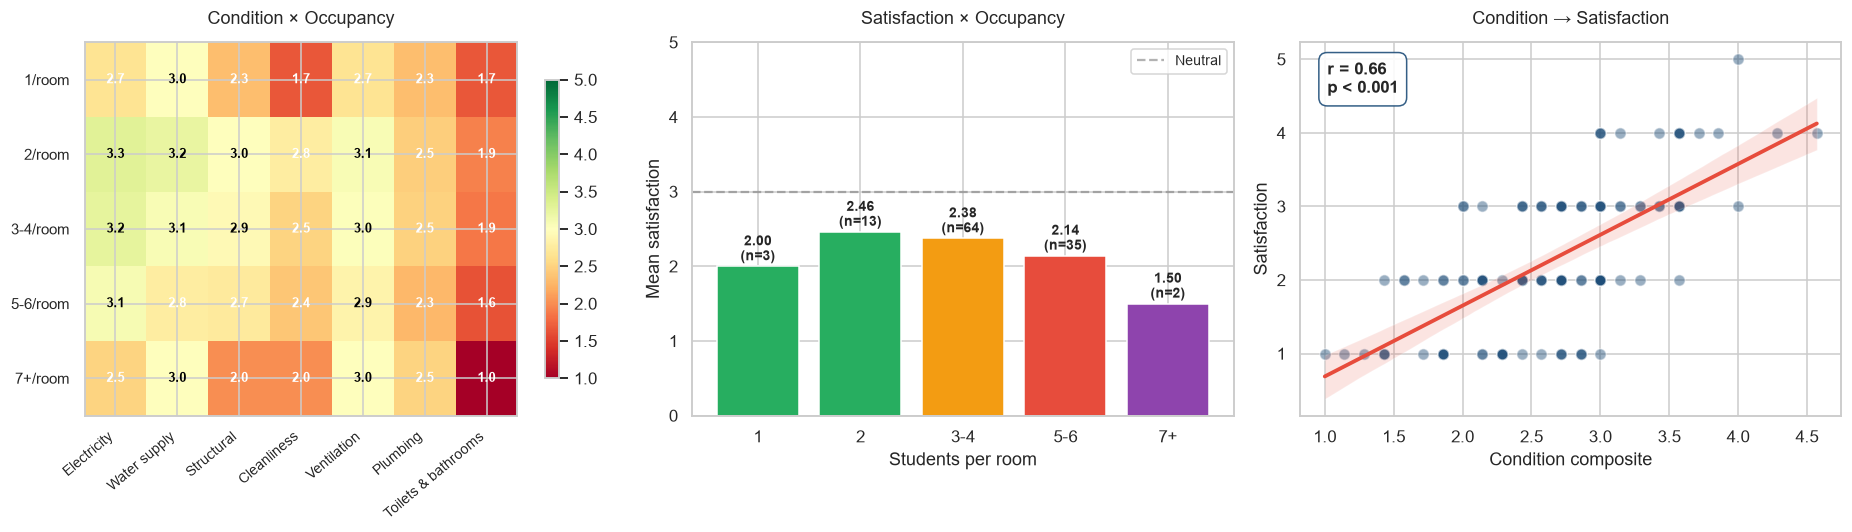

overcrowding vs dissatisfaction: chi2(4) = 1.601, p = 0.8087
male vs female satisfaction: t = 0.051, p = 0.9592
condition vs satisfaction: r = 0.663, p = 0.0000


In [24]:
# cross-tabs
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# condition × occupancy heatmap
ax1 = axes[0]
occ_order = [o for o in ['1', '2', '3-4', '5-6', '7+'] if (df['occ_c'] == o).sum() > 0]
fac_names = list(facilities.values())
heat = np.zeros((len(occ_order), len(fac_names)))
for i, o in enumerate(occ_order):
    sub = df[df['occ_c'] == o]
    for j, k in enumerate(facilities.keys()):
        heat[i, j] = sub[k].mean() if len(sub) else 0

im = ax1.imshow(heat, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)
ax1.set_xticks(range(len(fac_names)))
ax1.set_xticklabels(fac_names, rotation=40, ha='right', fontsize=9)
ax1.set_yticks(range(len(occ_order)))
ax1.set_yticklabels([f'{o}/room' for o in occ_order], fontsize=9.5)
for i in range(len(occ_order)):
    for j in range(len(fac_names)):
        ax1.text(j, i, f'{heat[i,j]:.1f}', ha='center', va='center',
                 fontsize=8.5, fontweight='bold',
                 color='white' if heat[i,j] < 2.8 or heat[i,j] > 4.5 else 'black')
ax1.set_title('Condition × Occupancy', pad=12)
plt.colorbar(im, ax=ax1, shrink=0.8)

# satisfaction by occupancy
ax2 = axes[1]
sat_by_occ = df.groupby('occ_c')['sat_n'].mean().reindex(occ_order).dropna()
ns = df.groupby('occ_c').size().reindex(occ_order).dropna()
colors_occ = [GREEN, GREEN, AMBER, RED, PURPLE][:len(sat_by_occ)]
bars = ax2.bar(sat_by_occ.index, sat_by_occ.values, color=colors_occ, edgecolor='white')
for b, v, n in zip(bars, sat_by_occ.values, ns.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.08, f'{v:.2f}\n(n={int(n)})',
             ha='center', fontsize=9, fontweight='bold')
ax2.axhline(3, ls='--', color='gray', alpha=0.6, label='Neutral')
ax2.set_xlabel('Students per room')
ax2.set_ylabel('Mean satisfaction')
ax2.set_ylim(0, 5)
ax2.set_title('Satisfaction × Occupancy', pad=12)
ax2.legend(fontsize=9)

# condition vs satisfaction scatter
ax3 = axes[2]
sns.regplot(data=df, x='cond_composite', y='sat_n',
            scatter_kws={'alpha': 0.45, 's': 55, 'color': BLUE, 'edgecolor': 'white'},
            line_kws={'color': RED, 'linewidth': 2.5}, ax=ax3)
r, p = pearsonr(df['cond_composite'], df['sat_n'])
ax3.text(0.05, 0.95, f'r = {r:.2f}\np < 0.001',
         transform=ax3.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                   edgecolor=BLUE, alpha=0.9))
ax3.set_xlabel('Condition composite')
ax3.set_ylabel('Satisfaction')
ax3.set_title('Condition → Satisfaction', pad=12)

plt.tight_layout()
plt.savefig('output_figures/fig9_cross.png', dpi=150, bbox_inches='tight')
plt.show()

# tests
ct = pd.crosstab(df['occ_c'], df['dissatisfied'])
chi2, p_chi, dof, _ = chi2_contingency(ct)
male = df[df['gender_c'] == 'Male']['sat_n']
female = df[df['gender_c'] == 'Female']['sat_n']
t, p_t = ttest_ind(male, female)

print(f"overcrowding vs dissatisfaction: chi2({dof}) = {chi2:.3f}, p = {p_chi:.4f}")
print(f"male vs female satisfaction: t = {t:.3f}, p = {p_t:.4f}")
print(f"condition vs satisfaction: r = {r:.3f}, p = {p:.4f}")

---
# 10. Interactive report

This cell writes `report.html` — a single file with a filter sidebar, KPI row, and seven tabs (one per questionnaire section). All charts are Plotly and respond to the slicers.

The same file works as a submitted report (Ctrl+P → Save as PDF) and as a live website (rename to `index.html` and push to GitHub Pages).

In [25]:
# build report.html
# row-level data so the browser can recompute on filter changes
rows_json = []
for _, r in df.iterrows():
    if pd.isna(r['sat_n']) or pd.isna(r['cond_composite']):
        continue
    rows_json.append({
        'g': r['gender_c'],
        'l': r['level_c'],
        'o': r['occ_c'],
        's': int(r['sat_n']),
        'c': [float(r[k]) if pd.notna(r[k]) else None for k in [c + '_n' for c in COND_COLS]],
        'rt': int(r['rt_n']) if pd.notna(r['rt_n']) else None,
        'knows': int(r['knows_n']),
        'bw': float(r['break_water_n']) if pd.notna(r['break_water_n']) else None,
        'be': float(r['break_electricity_n']) if pd.notna(r['break_electricity_n']) else None,
        'ag': [int(r[k]) if pd.notna(r[k]) else None for k in [c + '_n' for c in AGREE_COLS]],
        'im': [int(r['impact_academic_n']) if pd.notna(r['impact_academic_n']) else None,
               int(r['impact_health_n']) if pd.notna(r['impact_health_n']) else None],
        'pp': r['priority_c'],
    })

DATA_JSON = json.dumps(rows_json, separators=(',', ':'))

SHELL = r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Hostel Maintenance Report · UI 2026</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
:root{--p:#1f4e79;--a:#e74c3c;--s:#27ae60;--w:#f39c12;--n:#95a5a6;--u:#8e44ad;
      --bg:#f4f6fa;--card:#fff;--tx:#1a2332;--m:#6b7a8f;--b:#e5e9f0}
*{box-sizing:border-box;margin:0;padding:0}
html{scroll-behavior:smooth}
body{font-family:-apple-system,BlinkMacSystemFont,'Inter','Segoe UI',sans-serif;
     background:var(--bg);color:var(--tx);line-height:1.55;font-size:14px}

.top{background:linear-gradient(135deg,#1f4e79 0%,#2c6ea3 55%,#2ecc71 145%);
     color:#fff;padding:26px 32px}
.top h1{font-size:1.45rem;font-weight:800;letter-spacing:-.02em;margin-bottom:3px}
.top .sub{opacity:.9;font-size:.9rem}
.top .badges{margin-top:11px;display:flex;gap:8px;flex-wrap:wrap}
.badge{background:rgba(255,255,255,.2);padding:4px 10px;border-radius:20px;
       font-size:.72rem;font-weight:600}

.app{display:grid;grid-template-columns:220px 1fr;min-height:100vh}
.slicers{background:#fff;border-right:1px solid var(--b);padding:18px 14px;
         position:sticky;top:0;height:100vh;overflow-y:auto}
.slicers h3{font-size:.68rem;text-transform:uppercase;letter-spacing:.08em;
            color:var(--m);font-weight:800;margin:14px 0 6px}
.slicers h3:first-child{margin-top:0}
.slicers select{width:100%;padding:8px 10px;border:1.5px solid var(--b);
                border-radius:8px;font-size:.85rem;font-family:inherit;background:#fff;
                color:var(--tx);font-weight:500;cursor:pointer}
.slicers select:focus{outline:none;border-color:var(--p)}
.reset{margin-top:14px;width:100%;padding:9px;border:none;border-radius:8px;
       background:var(--p);color:#fff;font-weight:700;font-size:.82rem;
       cursor:pointer;font-family:inherit}
.reset:hover{opacity:.9}
.filter-info{margin-top:14px;font-size:.72rem;color:var(--m);line-height:1.5}
.filter-info strong{color:var(--p)}

.main{padding:18px 22px 60px;min-width:0}
.kpis{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:16px}
.kpi{background:var(--card);border-radius:10px;padding:14px 16px;
     border-left:4px solid var(--p);box-shadow:0 1px 4px rgba(0,0,0,.04)}
.kpi.a{border-left-color:var(--a)}.kpi.w{border-left-color:var(--w)}
.kpi.s{border-left-color:var(--s)}
.kpi .lbl{font-size:.65rem;color:var(--m);text-transform:uppercase;
          letter-spacing:.06em;font-weight:800;margin-bottom:4px}
.kpi .val{font-size:1.5rem;font-weight:800;color:var(--p);line-height:1;letter-spacing:-.02em}
.kpi.a .val{color:var(--a)}.kpi.w .val{color:#d68910}.kpi.s .val{color:var(--s)}
.kpi .sub{font-size:.68rem;color:var(--m);margin-top:4px}

.tabs{display:flex;gap:3px;margin-bottom:14px;border-bottom:2px solid var(--b);flex-wrap:wrap}
.tab{padding:9px 16px;border:none;background:none;font-size:.82rem;font-weight:700;
     color:var(--m);cursor:pointer;border-bottom:3px solid transparent;
     margin-bottom:-2px;font-family:inherit;transition:all .15s}
.tab:hover{color:var(--p)}.tab.active{color:var(--p);border-bottom-color:var(--p)}

.grid{display:grid;gap:14px;margin-bottom:14px}
.g2{grid-template-columns:1fr 1fr}
.g2a{grid-template-columns:1.5fr 1fr}
.g1{grid-template-columns:1fr}
.card{background:var(--card);border-radius:10px;padding:15px 17px;
      box-shadow:0 1px 4px rgba(0,0,0,.04);min-width:0;overflow:hidden}
.card h3{font-size:.78rem;color:var(--p);font-weight:800;margin-bottom:10px;
         text-transform:uppercase;letter-spacing:.04em}
.chart{width:100%;height:340px}.chart.tall{height:430px}.chart.short{height:260px}

.panel{display:none}.panel.active{display:block;animation:fi .22s}
@keyframes fi{from{opacity:0;transform:translateY(3px)}to{opacity:1;transform:translateY(0)}}

.insight{background:#fff;border-left:4px solid var(--p);padding:13px 17px;
         border-radius:8px;margin:12px 0;box-shadow:0 1px 4px rgba(0,0,0,.04);
         font-size:.87rem;line-height:1.55}
.insight.key{border-left-color:var(--a);background:#fdf6f5}
.insight h4{font-size:.72rem;text-transform:uppercase;letter-spacing:.05em;
            color:var(--p);margin-bottom:5px;font-weight:800}
.insight.key h4{color:var(--a)}

footer{text-align:center;padding:24px 20px;color:var(--m);font-size:.75rem;
       border-top:1px solid var(--b);margin-top:24px}
footer a{color:var(--p);text-decoration:none;font-weight:600}

@media (max-width:1024px){
  .app{grid-template-columns:1fr}
  .slicers{position:static;height:auto;border-right:none;border-bottom:1px solid var(--b)}
  .slicers-inner{display:grid;grid-template-columns:repeat(3,1fr);gap:10px}
  .slicers h3{margin-top:0}
  .kpis{grid-template-columns:repeat(2,1fr)}
  .g2,.g2a{grid-template-columns:1fr}
}
@media (max-width:560px){
  .top{padding:18px 16px}.top h1{font-size:1.15rem}
  .main{padding:10px}
  .kpis{gap:8px}
  .kpi{padding:11px 12px}.kpi .val{font-size:1.25rem}
  .slicers-inner{grid-template-columns:1fr 1fr}
  .tab{padding:8px 11px;font-size:.75rem}
  .chart{height:290px}.chart.tall{height:360px}
}
@media print{
  .slicers,.tabs{display:none}.app{grid-template-columns:1fr}.main{padding:0}
  .card{box-shadow:none;border:1px solid #ddd;page-break-inside:avoid}
  .top{background:#1f4e79!important;-webkit-print-color-adjust:exact;print-color-adjust:exact}
}
</style>
</head>
<body>

<div class="top">
  <h1>Hostel Maintenance Report</h1>
  <div class="sub">University of Ibadan · 2026 Survey · <span id="hdr-n">n = —</span></div>
  <div class="badges">
    <span class="badge">University of Ibadan</span>
    <span class="badge">September 2026</span>
    <span class="badge">Questionnaire-grounded</span>
    <span class="badge">Cross-filtered</span>
  </div>
</div>

<div class="app">
  <aside class="slicers">
    <div class="slicers-inner">
      <div><h3>Gender</h3><select id="f-g"><option value="">All</option></select></div>
      <div><h3>Level</h3><select id="f-l"><option value="">All</option></select></div>
      <div><h3>Occupancy</h3><select id="f-o"><option value="">All</option></select></div>
    </div>
    <button class="reset" onclick="resetAll()">Reset filters</button>
    <div class="filter-info">
      <strong>Cross-filter:</strong> changing a slicer updates every chart
      across every tab.
    </div>
  </aside>

  <main class="main">
    <div class="kpis">
      <div class="kpi"><div class="lbl">Students</div><div class="val" id="k-n">—</div><div class="sub">in current filter</div></div>
      <div class="kpi a"><div class="lbl">Dissatisfied</div><div class="val" id="k-d">—</div><div class="sub">Very Dissat. + Dissat.</div></div>
      <div class="kpi w"><div class="lbl">Condition</div><div class="val" id="k-c">—</div><div class="sub">mean / 5</div></div>
      <div class="kpi a"><div class="lbl">Slow response</div><div class="val" id="k-r">—</div><div class="sub">&gt; 1 month or never</div></div>
    </div>

    <div class="tabs">
      <button class="tab active" data-t="profile">Profile</button>
      <button class="tab" data-t="condition">Condition</button>
      <button class="tab" data-t="breakdown">Breakdowns</button>
      <button class="tab" data-t="reporting">Reporting</button>
      <button class="tab" data-t="governance">Governance</button>
      <button class="tab" data-t="impact">Impact</button>
      <button class="tab" data-t="priority">Priorities</button>
    </div>

    <div class="panel active" id="p-profile">
      <div class="grid g2">
        <div class="card"><h3>Q1. Gender</h3><div id="ch-gender" class="chart"></div></div>
        <div class="card"><h3>Q2. Level of study</h3><div id="ch-level" class="chart"></div></div>
      </div>
      <div class="grid g1">
        <div class="card"><h3>Q4. Room occupancy</h3><div id="ch-occ" class="chart short"></div></div>
      </div>
      <div class="insight key">
        <h4>Sample</h4>
        <p id="ins-profile"></p>
      </div>
    </div>

    <div class="panel" id="p-condition">
      <div class="grid g2a">
        <div class="card"><h3>Q5a. Condition ranking (95% CI)</h3><div id="ch-cond" class="chart tall"></div></div>
        <div class="card"><h3>Q5b. Rating distribution</h3><div id="ch-cond-dist" class="chart tall"></div></div>
      </div>
      <div class="insight key">
        <h4>Reading this</h4>
        <p id="ins-cond"></p>
      </div>
    </div>

    <div class="panel" id="p-breakdown">
      <div class="grid g1">
        <div class="card"><h3>Q6. Breakdowns per semester</h3><div id="ch-brk" class="chart tall"></div></div>
      </div>
      <div class="insight">
        <h4>Reliability</h4>
        <p id="ins-brk"></p>
      </div>
    </div>

    <div class="panel" id="p-reporting">
      <div class="grid g2">
        <div class="card"><h3>Q7. Knows reporting channel</h3><div id="ch-knows" class="chart"></div></div>
        <div class="card"><h3>Q8. Response time</h3><div id="ch-rt" class="chart"></div></div>
      </div>
      <div class="insight key">
        <h4>Pipeline</h4>
        <p id="ins-rt"></p>
      </div>
    </div>

    <div class="panel" id="p-governance">
      <div class="grid g1">
        <div class="card"><h3>Q9. Governance perceptions</h3><div id="ch-gov" class="chart tall"></div></div>
      </div>
      <div class="insight">
        <h4>Weakest item</h4>
        <p id="ins-gov"></p>
      </div>
    </div>

    <div class="panel" id="p-impact">
      <div class="grid g2">
        <div class="card"><h3>Q10. Impact on academics & health</h3><div id="ch-impact" class="chart"></div></div>
        <div class="card"><h3>Q11. Overall satisfaction</h3><div id="ch-sat" class="chart"></div></div>
      </div>
      <div class="insight key">
        <h4>Human impact</h4>
        <p id="ins-impact"></p>
      </div>
    </div>

    <div class="panel" id="p-priority">
      <div class="grid g2a">
        <div class="card"><h3>Q12. Priorities (Pareto)</h3><div id="ch-pri" class="chart tall"></div></div>
        <div class="card"><h3>Top priority share</h3><div id="ch-pri-pie" class="chart tall"></div></div>
      </div>
      <div class="insight key">
        <h4>First action</h4>
        <p id="ins-pri"></p>
      </div>
    </div>

  </main>
</div>

<footer>
  <p>2026 · [Your Name] · <a href="https://github.com/DevPepperspray">DevPepperspray</a></p>
  <p style="margin-top:4px;font-size:.72rem">Built with Python · pandas · scipy · Plotly.js</p>
</footer>

<script>
const DATA = __DATA_JSON__;
const CFG = {responsive:true, displaylogo:false,
             modeBarButtonsToRemove:['lasso2d','select2d','autoScale2d']};
const F = {family:'inherit', size:11};
const AX = {gridcolor:'#eef1f6', zerolinecolor:'#eef1f6'};
const FAC_LABELS = ['Structural','Toilets','Water','Electricity','Plumbing','Cleanliness','Ventilation'];
const SAT_LABELS = ['Very Dissatisfied','Dissatisfied','Neutral','Satisfied','Very Satisfied'];
const RT_LABELS  = ['≤ 1 day','≤ 1 week','≤ 1 month','Months','Never'];
const BRK_LABELS = ['Never','Once','2-3 times','4-5 times','>5 times'];
const AG_LABELS  = ['University responsible','Clear rules','Student participation','Complaint tracking','Adequate funding'];
const IMP_LABELS = ['None','Slight','Moderate','Strong','Very strong'];
const C = {p:'#1f4e79', a:'#e74c3c', s:'#27ae60', w:'#f39c12', n:'#95a5a6', u:'#8e44ad'};
const state = {g:'', l:'', o:''};

const mean = a => {const v = a.filter(x=>x!=null && !isNaN(x)); return v.length ? v.reduce((s,x)=>s+x,0)/v.length : 0;};
const count = (a,v) => a.filter(x=>x===v).length;
const uniq  = a => [...new Set(a)].filter(x=>x).sort();

function applyFilters(){
  return DATA.filter(r =>
    (!state.g || r.g === state.g) &&
    (!state.l || r.l === state.l) &&
    (!state.o || r.o === state.o));
}
function resetAll(){
  state.g=''; state.l=''; state.o='';
  ['f-g','f-l','f-o'].forEach(id => document.getElementById(id).value = '');
  renderAll();
}

function fill(id, values, placeholder){
  const s = document.getElementById(id);
  s.innerHTML = '<option value="">' + placeholder + '</option>';
  values.forEach(v => {
    const o = document.createElement('option');
    o.value = v; o.textContent = v;
    s.appendChild(o);
  });
}
fill('f-g', uniq(DATA.map(r=>r.g)), 'All genders');
fill('f-l', ['100L','200L','300L','400L','500L','600L','PG'].filter(x=>DATA.some(r=>r.l===x)), 'All levels');
fill('f-o', ['1','2','3-4','5-6','7+'].filter(x=>DATA.some(r=>r.o===x)), 'All occupancies');

['f-g','f-l','f-o'].forEach(id => {
  document.getElementById(id).addEventListener('change', e => {
    state[id.split('-')[1]] = e.target.value;
    renderAll();
  });
});

const LAY = (extra={}) => Object.assign({
  margin:{t:20,b:60,l:60,r:20}, font:F,
  plot_bgcolor:'white', paper_bgcolor:'white',
  xaxis:AX, yaxis:AX
}, extra);

function renderKPIs(rows){
  document.getElementById('hdr-n').textContent = `n = ${rows.length}`;
  document.getElementById('k-n').textContent = rows.length;
  const diss = rows.length ? rows.filter(r=>r.s<=2).length/rows.length*100 : 0;
  document.getElementById('k-d').textContent = diss.toFixed(1) + '%';
  document.getElementById('k-c').textContent = mean(rows.map(r=>mean(r.c))).toFixed(2);
  const slow = rows.length ? rows.filter(r=>r.rt>=3).length/rows.length*100 : 0;
  document.getElementById('k-r').textContent = slow.toFixed(0) + '%';

  const over = rows.filter(r=>r.o==='5-6'||r.o==='7+').length;
  document.getElementById('ins-profile').innerHTML =
    `<b>${rows.length}</b> respondents · ${over} (${rows.length?(over/rows.length*100).toFixed(0):0}%) live in rooms with 5+ people.`;

  const c = mean(rows.map(r=>mean(r.c)));
  document.getElementById('ins-cond').innerHTML =
    `Mean condition composite ${c.toFixed(2)}/5. Every facility sits below the "Fair" line.`;

  const frequent = rows.filter(r => r.be >= 4 || r.bw >= 4).length;
  document.getElementById('ins-brk').innerHTML =
    `${frequent} students (${rows.length?(frequent/rows.length*100).toFixed(0):0}%) see 4+ breakdowns per semester.`;

  const knows = rows.filter(r=>r.knows===1).length;
  const slowCount = rows.filter(r=>r.rt>=3).length;
  document.getElementById('ins-rt').innerHTML =
    `${knows} (${rows.length?(knows/rows.length*100).toFixed(0):0}%) know where to report · ${slowCount} (${rows.length?(slowCount/rows.length*100).toFixed(0):0}%) wait over a month.`;

  const tracking = rows.length ? rows.filter(r=>r.ag[3] >= 4).length/rows.length*100 : 0;
  document.getElementById('ins-gov').innerHTML =
    `Only ${tracking.toFixed(0)}% agree there's a clear complaint tracking system.`;

  const ha = rows.filter(r=>r.im[0]>=4).length;
  const hh = rows.filter(r=>r.im[1]>=4).length;
  document.getElementById('ins-impact').innerHTML =
    `${ha} report strong academic impact · ${hh} report strong health impact.`;

  const pri = {};
  rows.forEach(r => pri[r.pp] = (pri[r.pp]||0)+1);
  const top = Object.entries(pri).sort((a,b)=>b[1]-a[1])[0];
  if (top) document.getElementById('ins-pri').innerHTML =
    `Top request: <b>${top[0]}</b> (${top[1]} students, ${(top[1]/rows.length*100).toFixed(0)}%).`;
}

function renderGender(rows){
  const g = {};
  rows.forEach(r => g[r.g] = (g[r.g]||0)+1);
  Plotly.react('ch-gender', [{
    values: Object.values(g), labels: Object.keys(g), type:'pie', hole:0.55,
    marker:{colors:[C.p, C.a, C.w], line:{color:'white', width:3}},
    textinfo:'percent+label', textfont:{size:11, color:'white', family:'inherit'},
    hovertemplate:'<b>%{label}</b><br>%{value} students (%{percent})<extra></extra>'
  }], LAY({showlegend:false, margin:{t:10,b:10,l:10,r:10}}), CFG);
}

function renderLevel(rows){
  const order = ['100L','200L','300L','400L','500L','600L','PG'];
  const counts = order.map(l => rows.filter(r=>r.l===l).length);
  const labels = order.filter((_,i)=>counts[i]>0);
  const vals = counts.filter(v=>v>0);
  Plotly.react('ch-level', [{
    x: vals, y: labels, type:'bar', orientation:'h',
    marker:{color: C.p, line:{color:'white', width:1.5}},
    text: vals.map(v=>`${v} (${(v/rows.length*100).toFixed(0)}%)`),
    textposition:'outside', cliponaxis:false,
    hovertemplate:'<b>%{y}</b><br>%{x} students<extra></extra>'
  }], LAY({margin:{t:10, b:30, l:50, r:60}, showlegend:false,
           xaxis:{title:'Students', gridcolor:'#eef1f6'}}), CFG);
}

function renderOcc(rows){
  const order = ['1','2','3-4','5-6','7+'];
  const counts = order.map(o => rows.filter(r=>r.o===o).length);
  const colors = [C.s, C.s, C.w, C.a, C.u];
  Plotly.react('ch-occ', [{
    x: order, y: counts, type:'bar',
    marker:{color: colors, line:{color:'white', width:1.5}},
    text: counts.map(v=>v||''), textposition:'outside',
    hovertemplate:'<b>%{x} per room</b><br>%{y} students<extra></extra>'
  }], LAY({margin:{t:10, b:40, l:40, r:10}, showlegend:false,
           xaxis:{title:'Students per room', type:'category'},
           yaxis:{title:'Students', gridcolor:'#eef1f6'}}), CFG);
}

function renderCondition(rows){
  const means = FAC_LABELS.map((l,i)=>({l, v: mean(rows.map(r=>r.c[i]))}))
    .sort((a,b)=>a.v-b.v);
  const colors = means.map(m => m.v<2.5?C.a:m.v<3?C.w:C.s);
  Plotly.react('ch-cond', [{
    x: means.map(m=>m.v), y: means.map(m=>m.l), type:'bar', orientation:'h',
    marker:{color:colors, line:{color:'white', width:1.5}},
    text: means.map(m=>m.v.toFixed(2)), textposition:'outside', cliponaxis:false,
    hovertemplate:'<b>%{y}</b><br>Mean: %{x:.2f}/5<extra></extra>'
  }], LAY({
    showlegend:false, margin:{t:10, b:40, l:110, r:60},
    xaxis:{range:[0,5.4], title:'Mean (1=Very Poor, 5=Very Good)', gridcolor:'#eef1f6'},
    shapes:[{type:'line', x0:3, x1:3, y0:-0.5, y1:means.length-0.5,
             line:{color:'gray', width:1, dash:'dash'}}],
    annotations:[{x:3, y:means.length-0.3, text:'Fair', showarrow:false,
                  font:{size:9, color:'gray'}, xanchor:'left'}]
  }), CFG);
}

function renderConditionDist(rows){
  const ratings = ['Very Poor','Poor','Fair','Good','Very Good'];
  const colors = ['#c0392b','#e74c3c','#f39c12','#27ae60','#16a085'];
  const matrix = FAC_LABELS.map((_, i) => {
    const vals = rows.map(r=>r.c[i]).filter(v=>v!=null);
    const total = vals.length || 1;
    return [1,2,3,4,5].map(score => count(vals, score)/total*100);
  });
  const traces = ratings.map((rating, j) => ({
    name: rating,
    y: FAC_LABELS, x: matrix.map(row=>row[j]),
    type: 'bar', orientation: 'h',
    marker: {color: colors[j], line:{color:'white', width:1}},
    hovertemplate: `<b>%{y}</b><br>${rating}: %{x:.0f}%<extra></extra>`
  }));
  Plotly.react('ch-cond-dist', traces, LAY({
    barmode: 'stack',
    margin:{t:10, b:60, l:110, r:20},
    xaxis:{range:[0,100], title:'% of students'},
    showlegend:true,
    legend:{orientation:'h', y:-0.18, x:0.5, xanchor:'center', font:{size:9}}
  }), CFG);
}

function renderBreakdown(rows){
  const w = [0,0,0,0,0], e = [0,0,0,0,0];
  rows.forEach(r => {
    const map = {0:0, 1:1, 2.5:2, 4.5:3, 6:4};
    if (r.bw != null && map[r.bw] !== undefined) w[map[r.bw]]++;
    if (r.be != null && map[r.be] !== undefined) e[map[r.be]]++;
  });
  Plotly.react('ch-brk', [
    {name:'Water', x: BRK_LABELS, y: w, type:'bar',
     marker:{color: C.p, line:{color:'white', width:1.5}}},
    {name:'Electricity', x: BRK_LABELS, y: e, type:'bar',
     marker:{color: C.a, line:{color:'white', width:1.5}}}
  ], LAY({
    barmode:'group',
    margin:{t:10, b:60, l:50, r:10},
    xaxis:{title:'Breakdowns per semester'},
    yaxis:{title:'Students', gridcolor:'#eef1f6'},
    legend:{orientation:'h', y:-0.2, x:0.5, xanchor:'center', font:{size:10}}
  }), CFG);
}

function renderKnows(rows){
  const yes = rows.filter(r=>r.knows===1).length;
  const no  = rows.length - yes;
  Plotly.react('ch-knows', [{
    values:[yes, no], labels:['Knows channel','Does not know'],
    type:'pie', hole:0.55,
    marker:{colors:[C.s, C.a], line:{color:'white', width:3}},
    textinfo:'percent+label', textfont:{size:11, color:'white', family:'inherit'},
    hovertemplate:'<b>%{label}</b><br>%{value} students (%{percent})<extra></extra>'
  }], LAY({showlegend:false, margin:{t:10,b:30,l:10,r:10}}), CFG);
}

function renderRT(rows){
  const counts = [1,2,3,4,5].map(v => count(rows.map(r=>r.rt), v));
  const colors = [C.s, '#7dcea0', C.w, C.a, '#641e16'];
  Plotly.react('ch-rt', [{
    x: counts, y: RT_LABELS, type:'bar', orientation:'h',
    marker:{color: colors, line:{color:'white', width:1.5}},
    text: counts.map(v=>v||''), textposition:'outside', cliponaxis:false,
    hovertemplate:'<b>%{y}</b><br>%{x} students<extra></extra>'
  }], LAY({
    showlegend:false,
    margin:{t:10, b:30, l:130, r:50},
    xaxis:{title:'Students', gridcolor:'#eef1f6'}
  }), CFG);
}

function renderGov(rows){
  const means = AG_LABELS.map((_, i) => mean(rows.map(r=>r.ag[i])));
  Plotly.react('ch-gov', [{
    x: means, y: AG_LABELS, type:'bar', orientation:'h',
    marker:{color: means.map(v=>v<3?C.a:v<3.5?C.w:C.s),
            line:{color:'white', width:1.5}},
    text: means.map(v=>v.toFixed(2)), textposition:'outside', cliponaxis:false,
    hovertemplate:'<b>%{y}</b><br>Mean: %{x:.2f}/5<extra></extra>'
  }], LAY({
    showlegend:false, margin:{t:10, b:40, l:170, r:50},
    xaxis:{range:[0,5.5], title:'Mean agreement (1-5)', gridcolor:'#eef1f6'},
    shapes:[{type:'line', x0:3, x1:3, y0:-0.5, y1:AG_LABELS.length-0.5,
             line:{color:'gray', width:1, dash:'dash'}}]
  }), CFG);
}

function renderImpact(rows){
  const acad = [1,2,3,4,5].map(v => count(rows.map(r=>r.im[0]), v));
  const heal = [1,2,3,4,5].map(v => count(rows.map(r=>r.im[1]), v));
  Plotly.react('ch-impact', [
    {name:'Academic', x: IMP_LABELS, y: acad, type:'bar',
     marker:{color: C.p, line:{color:'white', width:1.5}}},
    {name:'Health & rest', x: IMP_LABELS, y: heal, type:'bar',
     marker:{color: C.a, line:{color:'white', width:1.5}}}
  ], LAY({
    barmode:'group', margin:{t:10, b:60, l:50, r:10},
    xaxis:{title:'Perceived impact'},
    yaxis:{title:'Students', gridcolor:'#eef1f6'},
    legend:{orientation:'h', y:-0.2, x:0.5, xanchor:'center', font:{size:10}}
  }), CFG);
}

function renderSat(rows){
  const counts = [1,2,3,4,5].map(v => count(rows.map(r=>r.s), v));
  const colors = ['#c0392b','#e74c3c','#95a5a6','#27ae60','#16a085'];
  Plotly.react('ch-sat', [{
    x: SAT_LABELS, y: counts, type:'bar',
    marker:{color: colors, line:{color:'white', width:1.5}},
    text: counts.map(v=>v||''), textposition:'outside',
    hovertemplate:'<b>%{x}</b><br>%{y} students<extra></extra>'
  }], LAY({
    showlegend:false, margin:{t:10, b:80, l:50, r:10},
    xaxis:{tickangle:-20, tickfont:{size:9}},
    yaxis:{title:'Students', gridcolor:'#eef1f6'}
  }), CFG);
}

function renderPriority(rows){
  const pri = {};
  rows.forEach(r => pri[r.pp] = (pri[r.pp]||0)+1);
  const entries = Object.entries(pri).sort((a,b)=>b[1]-a[1]).slice(0,8);
  const labels = entries.map(e=>e[0]);
  const values = entries.map(e=>e[1]);
  let acc = 0;
  const total = values.reduce((s,v)=>s+v,0);
  const cum = values.map(v => {acc += v; return acc/total*100;});

  Plotly.react('ch-pri', [
    {x: labels, y: values, type:'bar', name:'Students',
     marker:{color: labels.map((_,i)=> i<2?C.a: i<4?C.w: C.p),
             line:{color:'white', width:1.5}},
     text: values.map(v=>v), textposition:'outside',
     hovertemplate:'<b>%{x}</b><br>%{y} students<extra></extra>'},
    {x: labels, y: cum, type:'scatter', mode:'lines+markers+text',
     name:'Cumulative %', yaxis:'y2',
     line:{color: C.u, width:2.5},
     marker:{size:9, color:C.u, line:{color:'white', width:2}},
     text: cum.map(v=>`${v.toFixed(0)}%`), textposition:'top center',
     textfont:{size:8, color:C.u}}
  ], LAY({
    margin:{t:10, b:100, l:50, r:60},
    xaxis:{tickangle:-25, tickfont:{size:9}},
    yaxis:{title:'Students', gridcolor:'#eef1f6'},
    yaxis2:{title:'Cumulative %', overlaying:'y', side:'right',
            range:[0,110], showgrid:false, tickfont:{size:9}},
    legend:{orientation:'h', y:-0.35, x:0.5, xanchor:'center', font:{size:9}}
  }), CFG);
}

function renderPriorityPie(rows){
  const pri = {};
  rows.forEach(r => pri[r.pp] = (pri[r.pp]||0)+1);
  const entries = Object.entries(pri).sort((a,b)=>b[1]-a[1]).slice(0,5);
  const rest = Object.values(pri).reduce((s,v)=>s+v,0) - entries.reduce((s,e)=>s+e[1],0);
  if (rest > 0) entries.push(['Others', rest]);
  Plotly.react('ch-pri-pie', [{
    values: entries.map(e=>e[1]),
    labels: entries.map(e=>e[0]),
    type:'pie', hole:0.5,
    marker:{colors:[C.a, C.w, C.p, C.u, C.s, C.n], line:{color:'white', width:2}},
    textinfo:'percent+label', textfont:{size:10, color:'white', family:'inherit'},
    hovertemplate:'<b>%{label}</b><br>%{value} students (%{percent})<extra></extra>'
  }], LAY({showlegend:false, margin:{t:10,b:10,l:10,r:10}}), CFG);
}

function renderAll(){
  const rows = applyFilters();
  renderKPIs(rows);
  renderGender(rows);
  renderLevel(rows);
  renderOcc(rows);
  renderCondition(rows);
  renderConditionDist(rows);
  renderBreakdown(rows);
  renderKnows(rows);
  renderRT(rows);
  renderGov(rows);
  renderImpact(rows);
  renderSat(rows);
  renderPriority(rows);
  renderPriorityPie(rows);
}

document.querySelectorAll('.tab').forEach(t => {
  t.addEventListener('click', () => {
    document.querySelectorAll('.tab').forEach(x => x.classList.remove('active'));
    document.querySelectorAll('.panel').forEach(p => p.classList.remove('active'));
    t.classList.add('active');
    document.getElementById('p-' + t.dataset.t).classList.add('active');
    setTimeout(() => {
      document.querySelectorAll('#p-' + t.dataset.t + ' .js-plotly-plot')
        .forEach(el => Plotly.Plots.resize(el));
    }, 30);
  });
});

renderAll();
window.addEventListener('resize', () => {
  document.querySelectorAll('.js-plotly-plot').forEach(el => Plotly.Plots.resize(el));
});
</script>
</body>
</html>'''

final = SHELL.replace('__DATA_JSON__', DATA_JSON)
Path('report.html').write_text(final, encoding='utf-8')
print(f"wrote report.html ({len(final.encode('utf-8'))/1024:.1f} KB)")
print(f"rows embedded: {len(rows_json)}")

wrote report.html (43.7 KB)
rows embedded: 117


In [26]:
# preview the report inside the notebook
display(IFrame(src='report.html', width='100%', height=900))

from pathlib import Path as P
display(Markdown(f"[open report.html in browser]({P('report.html').resolve().as_uri()})"))


[open report.html in browser](file:///C:/Users/MY%20PC/Documents/Hostel%20Managment/report.html)

---
# 11. Summary

| Question | Result |
|---|---|
| Q5 condition | mean 2.51/5 — every facility below "Fair" |
| Q6 breakdowns | 60.8% see 4+ electrical failures per semester |
| Q7 awareness | 61.7% know the reporting channel |
| Q8 response time | only 7.5% fixed within a day; 43.9% take over a month |
| Q9 governance | complaint tracking is the weakest item |
| Q10 impact | 55.1% report strong health impact |
| Q11 satisfaction | 68.2% dissatisfied |
| Q12 priority | toilets/bathrooms (67.3%) |
| Q13 free text | toilet, bathroom, health, water dominate |

## Recommendations

1. Fix toilets and bathrooms first. They're rated worst and named first by students.
2. Publish the reporting channel — 41 students don't know where to report.
3. Introduce a complaint tracker. It's the weakest governance item.
4. Cap room occupancy at 4. Nearly half the students are above that.
5. Set a one-week response target for routine fixes. Current median is slower.

## Limits

- one university, one survey window
- self-reported, not physically inspected
- convenience sample, so there's likely some participation bias
- n=107 is too small for reliable subgroup analysis on 600L or PG students

